Rows and Columns: (1500, 8)

Column Names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5      

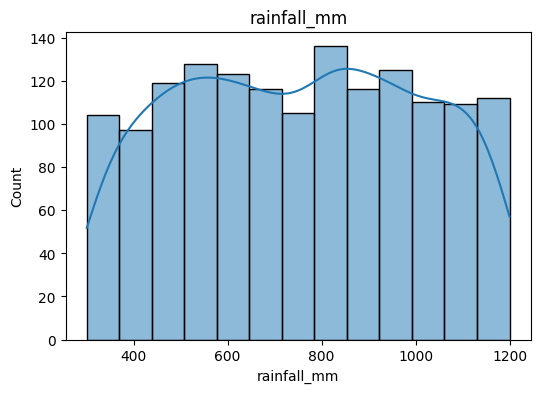

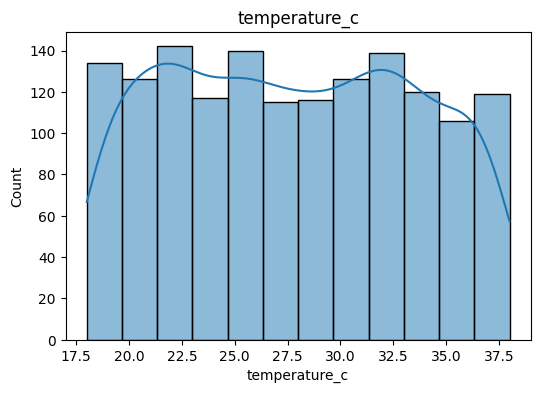

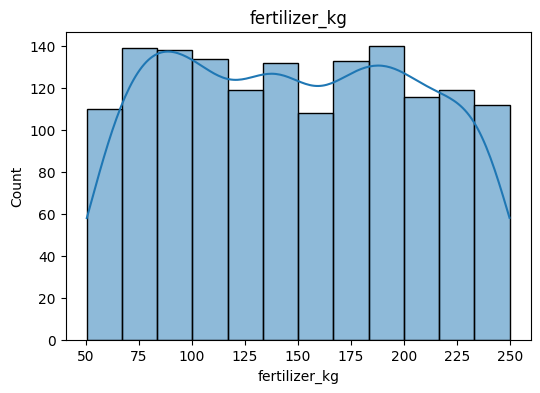

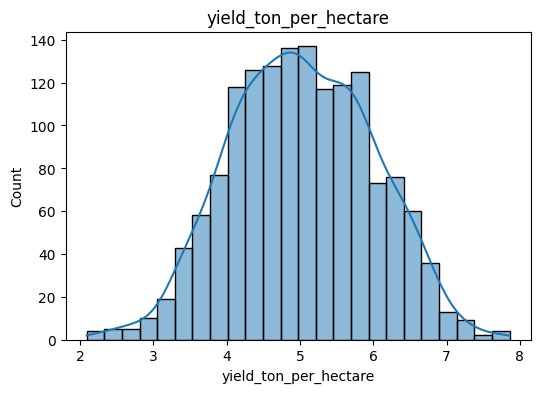

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


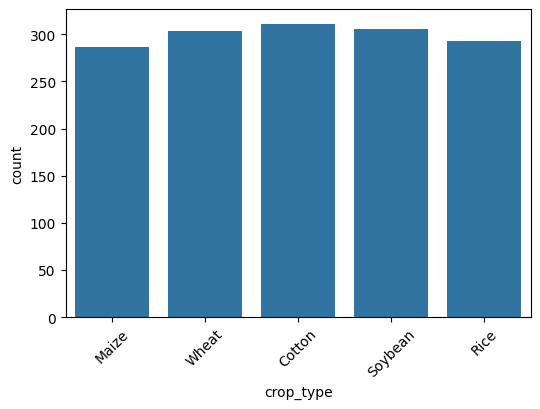

Most Frequent Crop:
Cotton
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


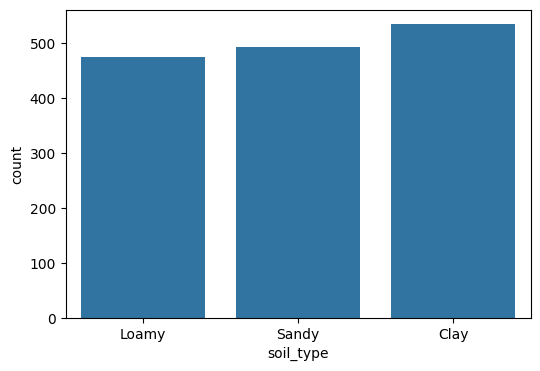

Most Common Soil:
Clay


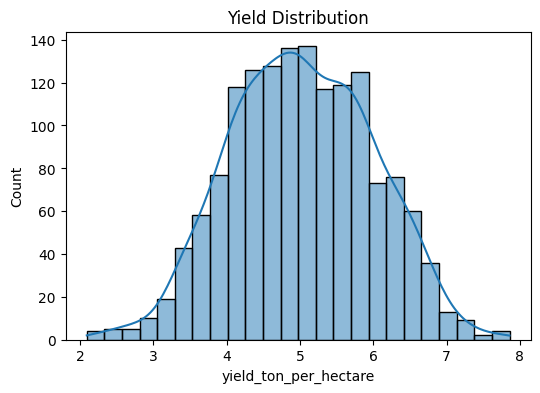

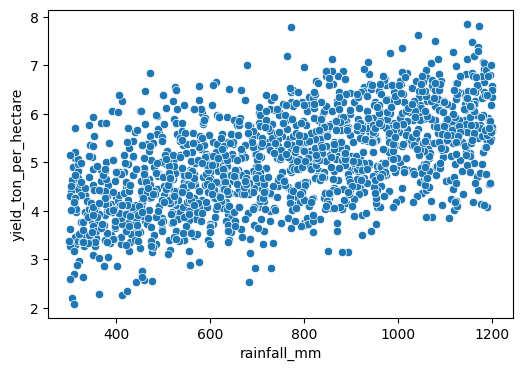

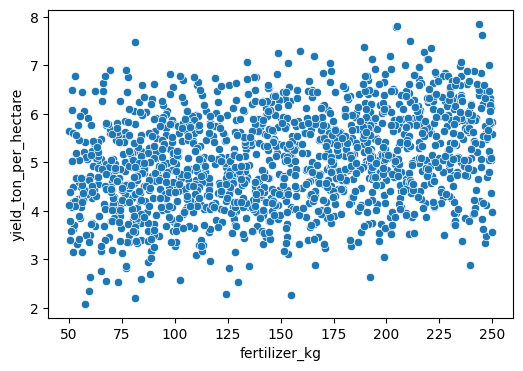

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

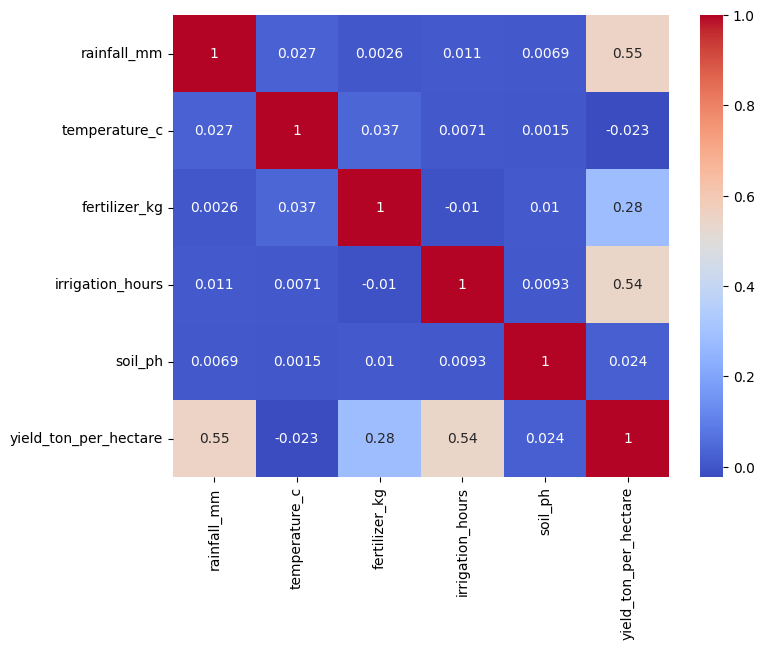

Top 3 Correlated Features:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
Name: yield_ton_per_hectare, dtype: float64
Average Yield by Crop:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6         

In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Q1 Dataset Overview

df = pd.read_csv("agriculture_yield.csv")

print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 10 Records:")
print(df.head(10))


# Q2 Data Types and Missing Values

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


# Q3 Descriptive Statistics

print("\nSummary Statistics:")
print(df.describe())

print("\nHighest Mean:")
print(df.mean(numeric_only=True).idxmax())

print("\nHighest Standard Deviation:")
print(df.std(numeric_only=True).idxmax())


# Q4 Distribution Analysis

columns = ['rainfall_mm',
           'temperature_c',
           'fertilizer_kg',
           'yield_ton_per_hectare']

for col in columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


# Q5 Crop Type Analysis

print(df['crop_type'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='crop_type', data=df)
plt.xticks(rotation=45)
plt.show()

print("Most Frequent Crop:")
print(df['crop_type'].value_counts().idxmax())


# Q6 Soil Type Analysis

print(df['soil_type'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='soil_type', data=df)
plt.show()

print("Most Common Soil:")
print(df['soil_type'].value_counts().idxmax())


# Q7 Yield Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], kde=True)
plt.title("Yield Distribution")
plt.show()


# Q8 Scatter Plot Analysis

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)
plt.show()


plt.figure(figsize=(6,4))
sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)
plt.show()


# Q9 Correlation Analysis

corr = df.corr(numeric_only=True)

print(corr)


plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()


print("Top 3 Correlated Features:")
print(
    corr['yield_ton_per_hectare']
    .sort_values(ascending=False)
    .head(4)
)


# Q10 Group Based Analysis

print("Average Yield by Crop:")
print(
    df.groupby('crop_type')
    ['yield_ton_per_hectare']
    .mean()
)


print("\nAverage Yield by Soil:")
print(
    df.groupby('soil_type')
    ['yield_ton_per_hectare']
    .mean()
)


# Q11 Feature Encoding

categorical = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical)


df_encoded = pd.get_dummies(
    df,
    columns=categorical
)

print(df_encoded.head())


# Q12 Feature Selection

X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

y = df_encoded['yield_ton_per_hectare']

print("Input Shape:", X.shape)
print("Target Shape:", y.shape)



# Q13 Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



# Q14 Linear Regression Model

model = LinearRegression()

model.fit(
    X_train,
    y_train
)


print("Intercept:")
print(model.intercept_)


print("\nCoefficients:")

coef = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})

print(coef)


print("\nHighest Positive Coefficient:")
print(
    coef.sort_values(
        by='Coefficient',
        ascending=False
    ).head(1)
)



# Model Evaluation

prediction = model.predict(X_test)

print("MSE:",
      mean_squared_error(y_test,prediction))


print("R2 Score:",
      r2_score(y_test,prediction))